In [1]:
import sys

custom_module_path = "/home/rebeccaz/Github/vampires_calibration"
if custom_module_path not in sys.path:
    sys.path.append(custom_module_path)

import instruments_jax as inst
import copy
import numpy as np
import json


# Step 1.a): Reading in csv - extracting single diffs and sums and configurations

In [2]:
file_path = "/home/rebeccaz/Github/vampires_calibration/data/20230914_processed_table.csv"
wavelength_string = 760
obs_mode = "MBI"

interleaved_values, interleaved_stds, configuration_list = inst.read_csv(file_path, 
    obs_mode = obs_mode, obs_filter = wavelength_string)
print("Interleaved Values")
print("Length: ", len(interleaved_values))
print(interleaved_values)
print("Interleaved Stds")
print("Length: ", len(interleaved_stds))
print(interleaved_stds[0 : 10])
print("Configuration List")
print("Length: ", len(configuration_list))
print(configuration_list)

print(interleaved_stds[0])

Interleaved Values
Length:  320
[ 19866.    23740.5  -22265.5   22477.5   13337.5   22094.5  -15543.5
  21181.5   -1825.5   18824.      110.    19143.5  -13889.    16562.
  12902.    17644.5  -14556.5   16335.5   13596.5   17653.    -3387.5
  18323.5    2077.    18801.5   12197.    21847.   -14083.    21064.
  20120.5   24137.5  -22436.    22875.5   15688.5   22780.   -17572.
  21883.    20161.    24039.5  -22381.    22674.75  12334.5   22139.5
 -14414.    21295.5   -3194.    18743.5    1604.5   19184.5  -14446.
  16557.    13502.    17758.   -13795.5   16484.5   13102.    17583.5
  -1688.5   18628.      432.    18979.5   13512.5   22046.   -15333.
  21198.5    3221.5   20141.    -4612.    20053.    17069.5   23260.
 -18755.5   22276.    20285.    24323.   -22433.    22960.    11280.5
  22175.   -13264.    21412.    -4602.    18669.     3141.5   19245.
 -14799.5   16621.5   13886.    17961.   -12891.    16749.    12270.
  17794.     -109.    18976.    -1109.    19212.    -9865.5   1743

In [3]:
%%timeit

import copy


copy.deepcopy(interleaved_values)

7.08 µs ± 1.96 µs per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


# Step 1.b) - Make plot of existing values as double diffs and sums

# Step 2: Creating a system Mueller matrix object

In [4]:
# Loading in previous fit from vampires_calibration
from pathlib import Path

fallback_filename = "/home/rebeccaz/Github/vampires_calibration/scipy_minimize/intermediate_data_files/750-50_no_IMR_offset_fixed_EM_gain_iterate_on_any_improvement_ideal_start_table_phi_with_dichroic_best_fit_EM_gain_1.txt"
saved_fit_filename = f"/home/rebeccaz/Github/vampires_calibration/scipy_minimize/intermediate_data_files/{wavelength_string}_no_IMR_offset_fixed_EM_gain_1_no_retardance_constraints_iterate_on_any_improvement_from_broadband_ideal_start_table_phi_with_dichroic_best_fit_old_fit_values.txt"

if Path(saved_fit_filename).exists():
    filename = saved_fit_filename
    print("Resuming from saved MBI scipy.minimize fit: " + filename)
else:
    filename = fallback_filename
    print("Starting from closest broadband filter fit: " + filename)
with open(filename, "r") as f:
    past_fit = json.load(f)
past_fit.pop("wollaston", None)
past_fit.setdefault("image_rotator", {})
past_fit["image_rotator"].pop("delta_theta", None)

print(past_fit)

theta_pol = past_fit["lp"]["theta"]
delta_HWP = past_fit["hwp"]["phi"] 
offset_HWP = past_fit["hwp"]["delta_theta"]
delta_derot = past_fit["image_rotator"]["phi"] 
offset_derot = 0
delta_opts = past_fit["optics"]["phi"]
epsilon_opts = past_fit["optics"]["epsilon"]
rot_opts = past_fit["optics"]["theta"]
delta_FLC = past_fit["flc"]["phi"] 
rot_FLC = past_fit["flc"]["delta_theta"]
dichroic_phi = past_fit.get("dichroic", {}).get("phi", 0)
dichroic_epsilon = past_fit.get("dichroic", {}).get("epsilon", 0)
dichroic_theta = past_fit.get("dichroic", {}).get("theta", 0)
em_gain = 1.0  # Fixed ideal EM gain

# Based on values in Six_And_Eleven_Parameter_Model_Best_MCMC_and_Scipy_Fits Google Sheets - having zeros for angles that're too large
# theta_pol = 0
# delta_HWP = 0.451  # Add your actual delta_HWP value
# offset_HWP = -2.642  # Add your actual offset_HWP value
# delta_derot = 0.32  # Add your actual delta_derot value
# offset_derot = 0  # Add your actual offset_derot value
# delta_opts = 0  # Add your actual delta_opts value
# epsilon_opts = 0  # Add your actual epsilon_opts value
# rot_opts = 0  # Add your actual rot_opts value
# delta_FLC = 0.5  # Add your actual delta_FLC value
# rot_FLC = 0  # Add your actual rot_FLC value
# em_gain = 1.2  # Add your actual em_gain value

# NOTE: Components must be listed downstream to upstream
# Define the instrument configuration as a system dictionary
system_dict = {
    "components": {
        "wollaston": {
            "type": "wollaston_prism_function",
            "properties": {"beam": "o", "transmission_ratio": em_gain},
        },
        "dichroic": {
            "type": "diattenuator_retarder_function",
            "properties": {"phi": dichroic_phi, "epsilon": dichroic_epsilon, "theta": dichroic_theta},
        },
        "flc": {
            "type": "general_retarder_function",
            "properties": {"phi": delta_FLC, "theta": 0, "delta_theta": rot_FLC},
        },
        "optics": {
            "type": "diattenuator_retarder_function",
            "properties": {"phi": delta_opts, "epsilon": epsilon_opts, "theta": rot_opts},
        },
        "image_rotator": {
            "type": "general_retarder_function",
            "properties": {"phi": delta_derot, "theta": 0, "delta_theta": 0},
        },
        "hwp": {
            "type": "general_retarder_function",
            "properties": {"phi": delta_HWP, "theta": 0, "delta_theta": offset_HWP},
        },
        "lp": {
            "type": "general_linear_polarizer_function_with_theta",
            "properties": {"theta": theta_pol},
        }
    }
}

Starting from closest broadband filter fit: /home/rebeccaz/Github/vampires_calibration/scipy_minimize/intermediate_data_files/750-50_no_IMR_offset_fixed_EM_gain_iterate_on_any_improvement_ideal_start_table_phi_with_dichroic_best_fit_EM_gain_1.txt
{'dichroic': {'phi': -0.4040235351895908, 'epsilon': 0.14019674097073492, 'theta': 25.01871302102132}, 'flc': {'phi': 3.6702262824592626, 'delta_theta': 4.999999999776886}, 'optics': {'phi': 0.8926390294348794, 'epsilon': 6.035467842878573e-13, 'theta': -17.1933566890572}, 'image_rotator': {'phi': 3.0667998131141854}, 'hwp': {'phi': 2.9883397947561496, 'delta_theta': -2.4281406522445756}, 'lp': {'theta': -5.0}}


In [5]:
# Converting system dictionary into system Mueller Matrix object

system_mm = inst.generate_system_mueller_matrix(system_dict)
print(system_mm.evaluate())

[[ 0.50220721  0.49457755 -0.08720737  0.        ]
 [ 0.50220721  0.49457755 -0.08720737  0.        ]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]


# Step 4: Creating a dictionary of p0 starting guesses

{'dichroic': {'phi': -0.4040235351895908, 'epsilon': 0.14019674097073492, 'theta': 25.01871302102132}, 'flc': {'phi': 3.6702262824592626, 'delta_theta': 4.999999999776886}, 'optics': {'phi': 0.8926390294348794, 'epsilon': 6.035467842878573e-13, 'theta': -17.1933566890572}, 'image_rotator': {'phi': 3.0667998131141854}, 'hwp': {'phi': 2.9883397947561496, 'delta_theta': -2.4281406522445756}, 'lp': {'theta': -5.0}}
logl value: 8796.894186102294


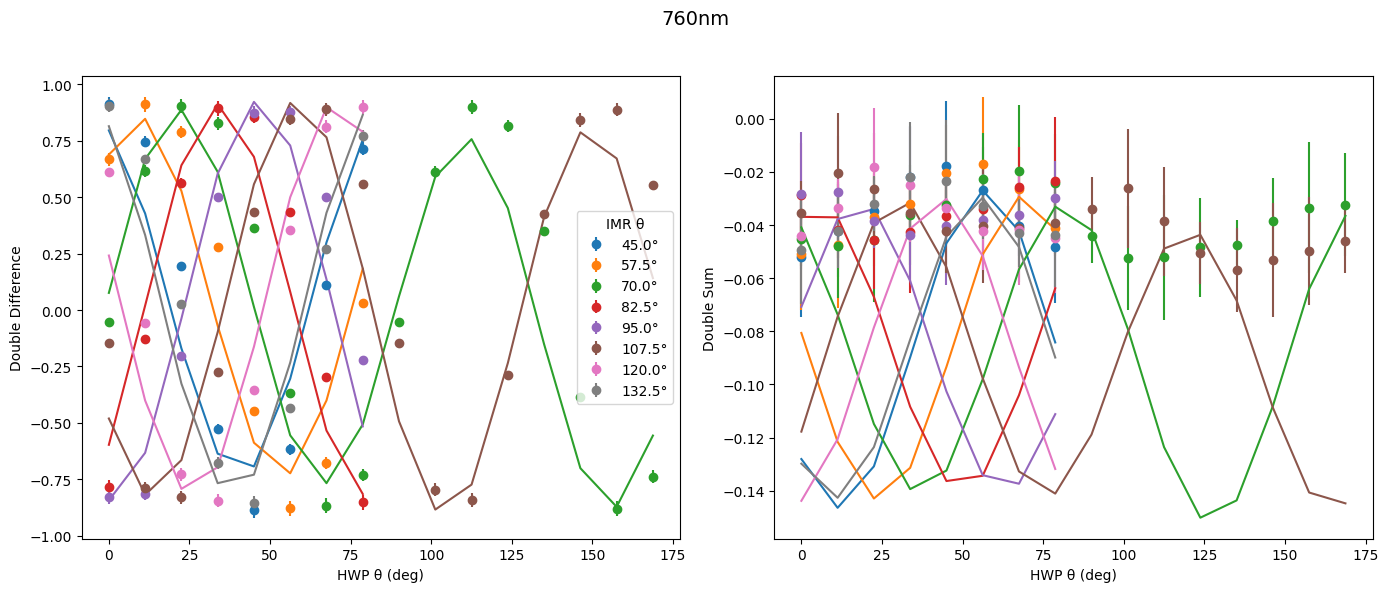

In [6]:
# Fitting all non-EM-gain parameters
p0 = copy.deepcopy(past_fit)
p0.pop("wollaston", None)

print(p0)

p0_values, p0_keywords = inst.parse_configuration(p0)
s_in = np.array([1, 0, 0, 0])
logl_value = inst.logl(p0_values, p0_keywords, system_mm, interleaved_values, interleaved_stds, configuration_list,
    s_in=s_in, logl_function=None, process_dataset=inst.process_dataset, process_errors=inst.process_errors, 
    process_model=inst.process_model)
print("logl value: " + str(logl_value))

# TODO: Add an initial plot block here
# Plotting intial plot
updated_system_mm = inst.update_system_mm(p0_values, p0_keywords, system_mm)
model = inst.model(p0_values, p0_keywords, system_mm, configuration_list, 
    process_model = inst.process_model)

inst.plot_data_and_model(interleaved_values, interleaved_stds, model, 
    configuration_list, wavelength = wavelength_string)

# Step 5: Running minimize_system_Mueller_matrix iteratively

Before p0: {'dichroic': {'phi': -0.4040235351895908, 'epsilon': 0.14019674097073492, 'theta': 25.01871302102132}, 'flc': {'phi': 3.6702262824592626, 'delta_theta': 4.999999999776886}, 'optics': {'phi': 0.8926390294348794, 'epsilon': 6.035467842878573e-13, 'theta': -17.1933566890572}, 'image_rotator': {'phi': 3.0667998131141854}, 'hwp': {'phi': 2.9883397947561496, 'delta_theta': -2.4281406522445756}, 'lp': {'theta': -5.0}}
Iteration #: 1
logl_value: 1392.186225879037
Best Fit Parameters: [-3.48027905e-01  4.39234849e-02  1.17581412e+01  3.44413484e+00
  1.63205742e+00  1.02428335e+00  1.09551949e-13 -1.52175432e+01
  3.16064419e+00  2.92142759e+00 -2.74465523e+00 -5.00000000e+00]
After p0: {'dichroic': {'phi': -0.34802790512757, 'epsilon': 0.043923484919174055, 'theta': 11.758141161282765}, 'flc': {'phi': 3.4441348448371576, 'delta_theta': 1.6320574239001666}, 'optics': {'phi': 1.02428335255187, 'epsilon': 1.095519488063946e-13, 'theta': -15.217543207145397}, 'image_rotator': {'phi': 3.

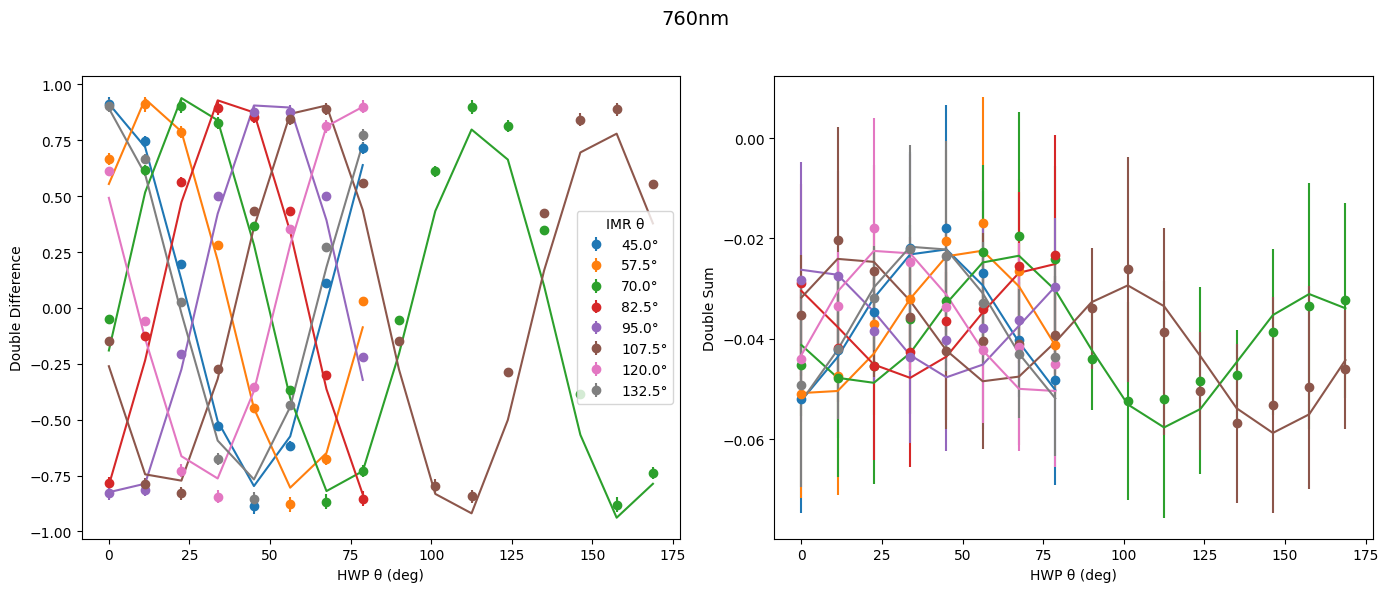

Before p0: {'dichroic': {'phi': -0.34802790512757, 'epsilon': 0.043923484919174055, 'theta': 11.758141161282765}, 'flc': {'phi': 3.4441348448371576, 'delta_theta': 1.6320574239001666}, 'optics': {'phi': 1.02428335255187, 'epsilon': 1.095519488063946e-13, 'theta': -15.217543207145397}, 'image_rotator': {'phi': 3.1606441868297273}, 'hwp': {'phi': 2.9214275895951722, 'delta_theta': -2.7446552314730477}, 'lp': {'theta': -5.0}}
Iteration #: 2
logl_value: 1389.6465248408565
Best Fit Parameters: [-1.07348303e+00  4.12259736e-02  4.48605116e+00  3.45309797e+00
  2.22560151e+00  1.10308595e+00  5.46194604e-13 -1.45624502e+01
  3.15154359e+00  2.91549135e+00 -2.29471907e+00 -5.00000000e+00]
After p0: {'dichroic': {'phi': -1.0734830262299377, 'epsilon': 0.041225973623696774, 'theta': 4.486051164819891}, 'flc': {'phi': 3.4530979696402717, 'delta_theta': 2.2256015110169587}, 'optics': {'phi': 1.1030859488550449, 'epsilon': 5.46194604270207e-13, 'theta': -14.562450161188288}, 'image_rotator': {'phi'

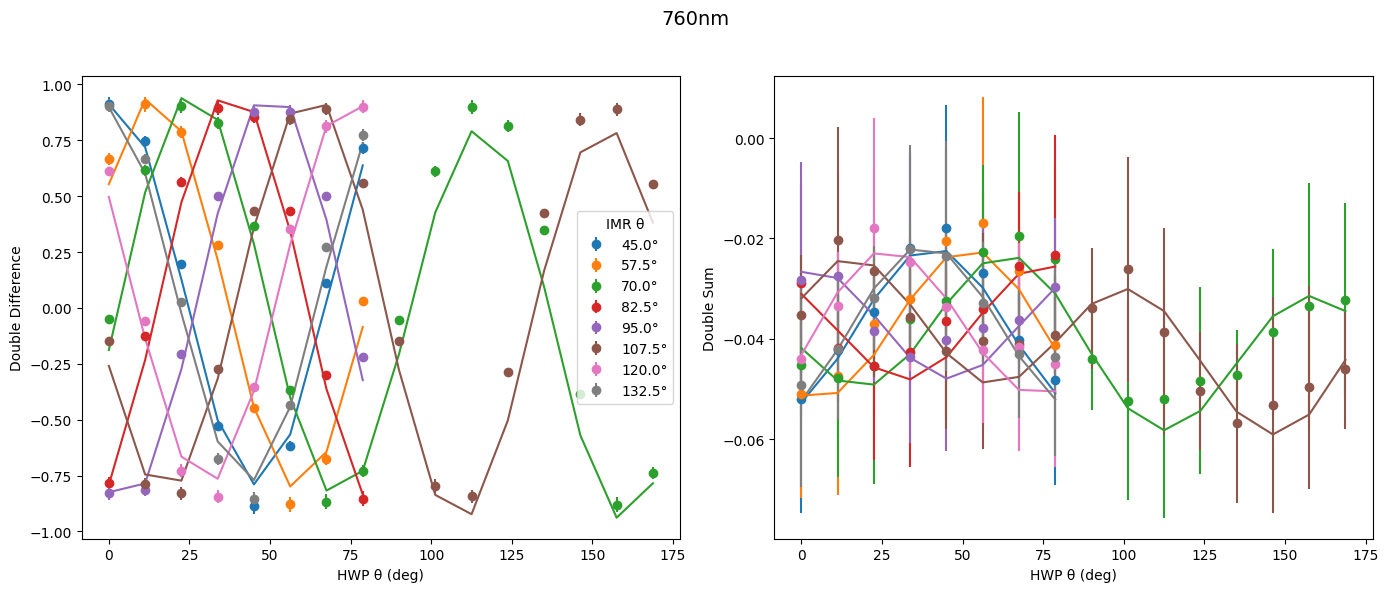

Before p0: {'dichroic': {'phi': -1.0734830262299377, 'epsilon': 0.041225973623696774, 'theta': 4.486051164819891}, 'flc': {'phi': 3.4530979696402717, 'delta_theta': 2.2256015110169587}, 'optics': {'phi': 1.1030859488550449, 'epsilon': 5.46194604270207e-13, 'theta': -14.562450161188288}, 'image_rotator': {'phi': 3.151543593808479}, 'hwp': {'phi': 2.9154913543978216, 'delta_theta': -2.294719066226744}, 'lp': {'theta': -5.0}}
Iteration #: 3
logl_value: 1386.1068434464169
Best Fit Parameters: [-1.23900633e+00  4.21376396e-02  5.58010263e+00  3.50760265e+00
  3.56224548e+00  1.68911874e+00  6.49906802e-12 -8.07175900e+00
  3.15224775e+00  2.91819875e+00 -1.17508527e+00 -5.00000000e+00]
After p0: {'dichroic': {'phi': -1.239006331767412, 'epsilon': 0.04213763959988297, 'theta': 5.5801026304346255}, 'flc': {'phi': 3.5076026508938956, 'delta_theta': 3.562245478001415}, 'optics': {'phi': 1.6891187377614667, 'epsilon': 6.499068024056891e-12, 'theta': -8.071758996717943}, 'image_rotator': {'phi': 

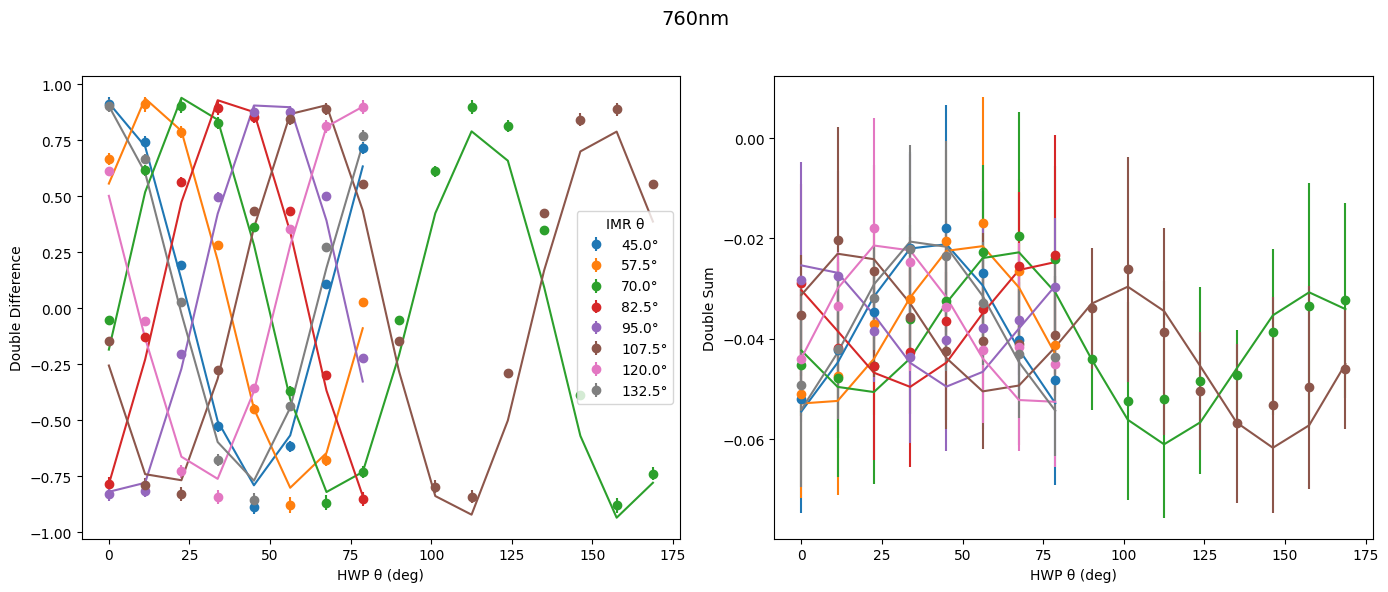

Before p0: {'dichroic': {'phi': -1.239006331767412, 'epsilon': 0.04213763959988297, 'theta': 5.5801026304346255}, 'flc': {'phi': 3.5076026508938956, 'delta_theta': 3.562245478001415}, 'optics': {'phi': 1.6891187377614667, 'epsilon': 6.499068024056891e-12, 'theta': -8.071758996717943}, 'image_rotator': {'phi': 3.1522477536045566}, 'hwp': {'phi': 2.918198751281915, 'delta_theta': -1.1750852660768105}, 'lp': {'theta': -5.0}}
Iteration #: 4
logl_value: 1384.9294741242065
Best Fit Parameters: [-1.62025377e+00  4.20595923e-02  5.18103511e+00  3.50480289e+00
  4.99103804e+00  1.68456053e+00  3.46865065e-12 -6.92157601e+00
  3.15262595e+00  2.91675564e+00 -1.79513053e+00 -5.00000000e+00]
After p0: {'dichroic': {'phi': -1.620253768572466, 'epsilon': 0.042059592328856976, 'theta': 5.181035112376122}, 'flc': {'phi': 3.504802894210208, 'delta_theta': 4.991038039773109}, 'optics': {'phi': 1.6845605302370075, 'epsilon': 3.468650654150282e-12, 'theta': -6.921576008863827}, 'image_rotator': {'phi': 3.

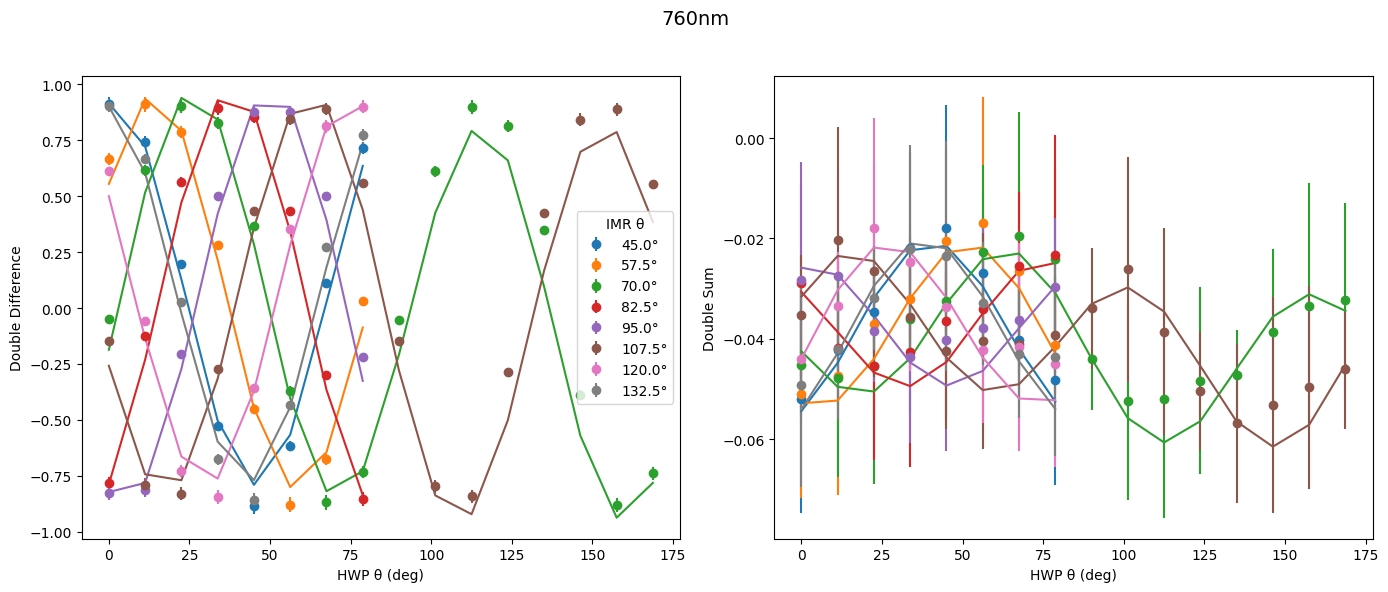

Before p0: {'dichroic': {'phi': -1.620253768572466, 'epsilon': 0.042059592328856976, 'theta': 5.181035112376122}, 'flc': {'phi': 3.504802894210208, 'delta_theta': 4.991038039773109}, 'optics': {'phi': 1.6845605302370075, 'epsilon': 3.468650654150282e-12, 'theta': -6.921576008863827}, 'image_rotator': {'phi': 3.1526259471906783}, 'hwp': {'phi': 2.9167556444465106, 'delta_theta': -1.7951305330573364}, 'lp': {'theta': -5.0}}
Iteration #: 5
logl_value: 1384.5423626677366
Best Fit Parameters: [-1.14492621e+00  4.23189523e-02  6.10926708e+00  3.50172886e+00
  4.99998518e+00  1.76726273e+00  4.98745230e-11 -4.77803570e+00
  3.15292905e+00  2.91682960e+00 -2.10389078e+00 -5.00000000e+00]
After p0: {'dichroic': {'phi': -1.144926211304154, 'epsilon': 0.04231895232778847, 'theta': 6.109267077038611}, 'flc': {'phi': 3.5017288603854286, 'delta_theta': 4.999985180491847}, 'optics': {'phi': 1.7672627305545578, 'epsilon': 4.9874523028015585e-11, 'theta': -4.778035697412085}, 'image_rotator': {'phi': 3

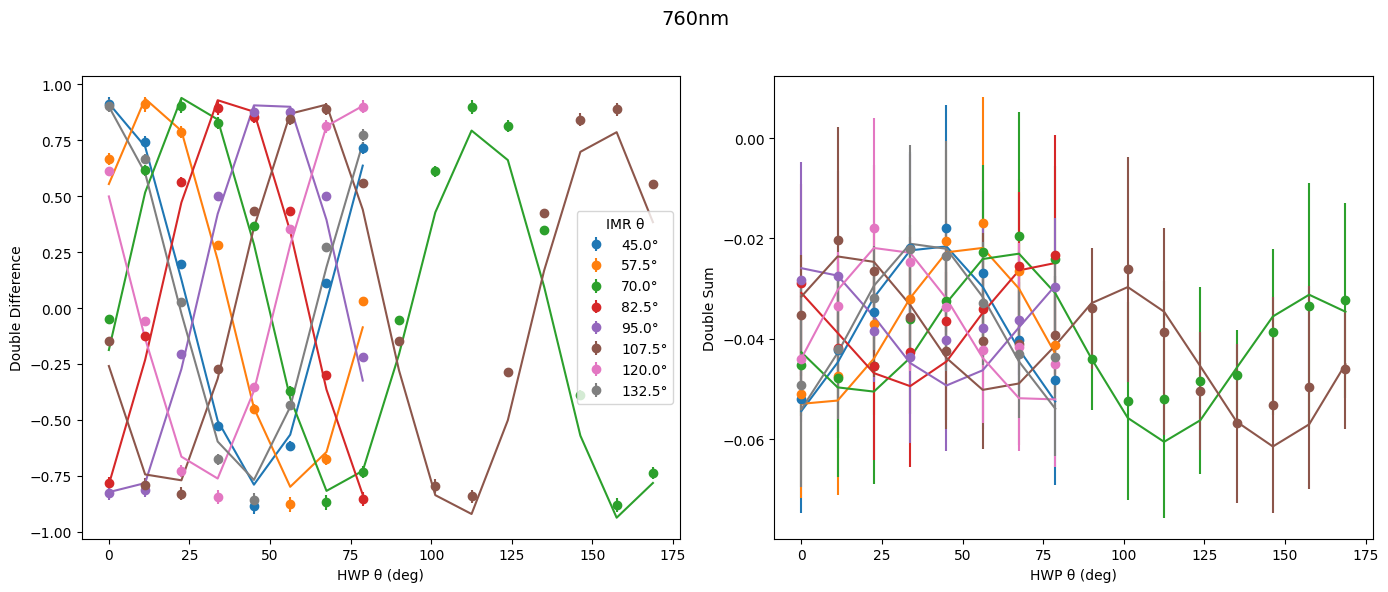

Before p0: {'dichroic': {'phi': -1.144926211304154, 'epsilon': 0.04231895232778847, 'theta': 6.109267077038611}, 'flc': {'phi': 3.5017288603854286, 'delta_theta': 4.999985180491847}, 'optics': {'phi': 1.7672627305545578, 'epsilon': 4.9874523028015585e-11, 'theta': -4.778035697412085}, 'image_rotator': {'phi': 3.152929047227757}, 'hwp': {'phi': 2.9168296007040873, 'delta_theta': -2.103890782770605}, 'lp': {'theta': -5.0}}
Iteration #: 6
logl_value: 1384.5423499257317
Best Fit Parameters: [-1.14473027  0.04231836  6.10976869  3.5017127   4.99999993  1.76728906
  0.         -4.77783093  3.15293373  2.91683391 -2.10355085 -5.        ]
After p0: {'dichroic': {'phi': -1.144730268304348, 'epsilon': 0.04231835856320902, 'theta': 6.109768692831137}, 'flc': {'phi': 3.5017127035840705, 'delta_theta': 4.999999929524327}, 'optics': {'phi': 1.7672890551003593, 'epsilon': 0.0, 'theta': -4.777830925674523}, 'image_rotator': {'phi': 3.1529337337295047}, 'hwp': {'phi': 2.9168339114742086, 'delta_theta':

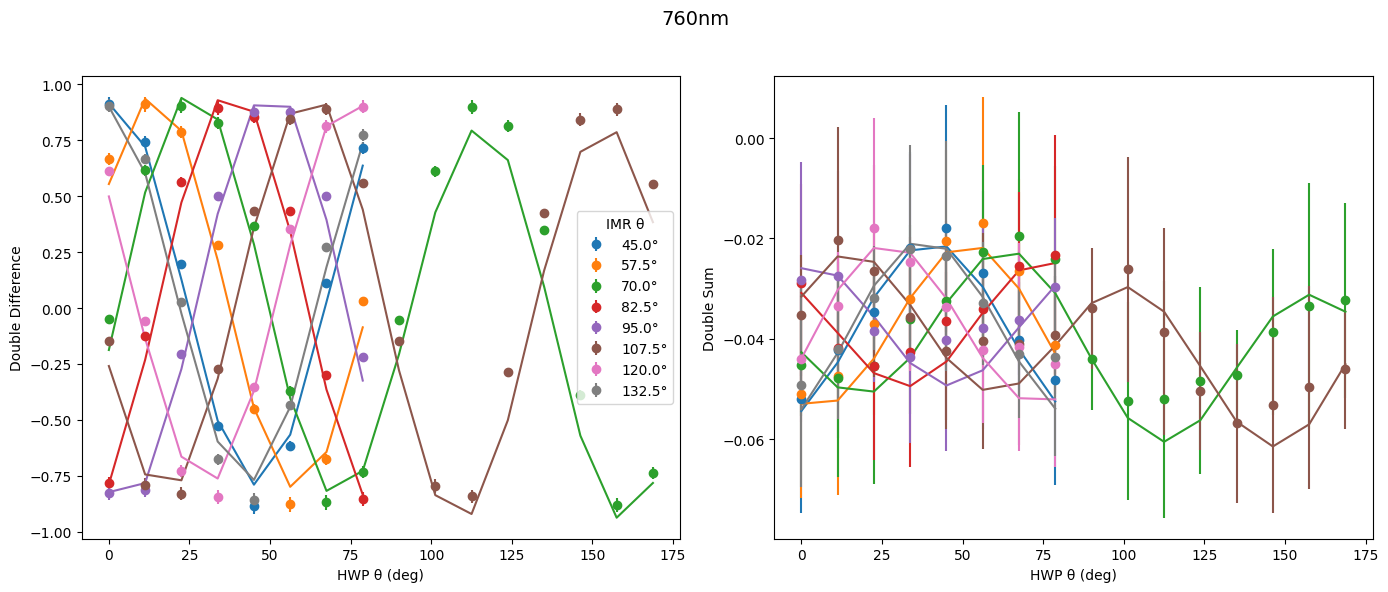

Before p0: {'dichroic': {'phi': -1.144730268304348, 'epsilon': 0.04231835856320902, 'theta': 6.109768692831137}, 'flc': {'phi': 3.5017127035840705, 'delta_theta': 4.999999929524327}, 'optics': {'phi': 1.7672890551003593, 'epsilon': 0.0, 'theta': -4.777830925674523}, 'image_rotator': {'phi': 3.1529337337295047}, 'hwp': {'phi': 2.9168339114742086, 'delta_theta': -2.1035508534088363}, 'lp': {'theta': -5.0}}
Iteration #: 7
logl_value: 1384.5423498833925
Best Fit Parameters: [-1.14473711e+00  4.23186534e-02  6.10985644e+00  3.50172011e+00
  4.99999996e+00  1.76728714e+00  1.06677962e-12 -4.77785419e+00
  3.15293443e+00  2.91683499e+00 -2.10361482e+00 -5.00000000e+00]
After p0: {'dichroic': {'phi': -1.1447371060577864, 'epsilon': 0.0423186533871581, 'theta': 6.109856437776964}, 'flc': {'phi': 3.5017201070603514, 'delta_theta': 4.999999962624495}, 'optics': {'phi': 1.7672871372571368, 'epsilon': 1.0667796160286186e-12, 'theta': -4.77785419496904}, 'image_rotator': {'phi': 3.1529344282907257},

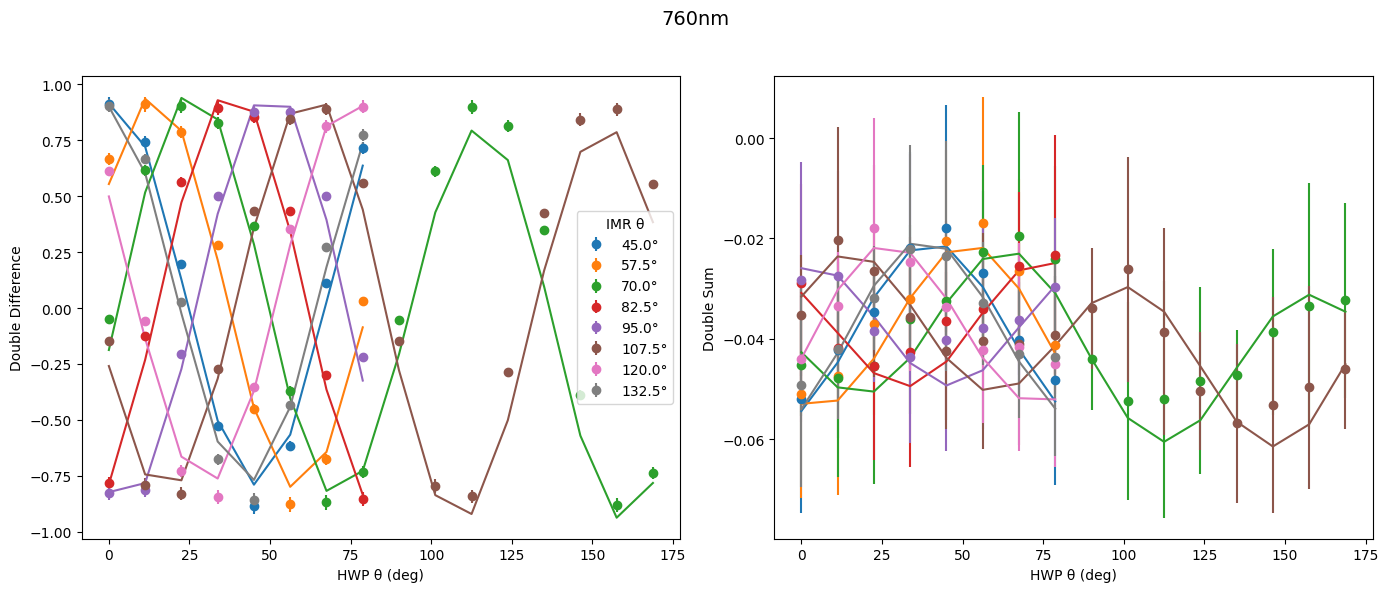

Before p0: {'dichroic': {'phi': -1.1447371060577864, 'epsilon': 0.0423186533871581, 'theta': 6.109856437776964}, 'flc': {'phi': 3.5017201070603514, 'delta_theta': 4.999999962624495}, 'optics': {'phi': 1.7672871372571368, 'epsilon': 1.0667796160286186e-12, 'theta': -4.77785419496904}, 'image_rotator': {'phi': 3.1529344282907257}, 'hwp': {'phi': 2.9168349936502587, 'delta_theta': -2.1036148237807692}, 'lp': {'theta': -5.0}}
Iteration #: 8
logl_value: 1384.5423496937728
Best Fit Parameters: [-1.14471049e+00  4.23188335e-02  6.10983574e+00  3.50171354e+00
  4.99999998e+00  1.76727064e+00  1.06227064e-12 -4.77781274e+00
  3.15293233e+00  2.91683466e+00 -2.10368316e+00 -5.00000000e+00]
After p0: {'dichroic': {'phi': -1.1447104924699028, 'epsilon': 0.04231883352999419, 'theta': 6.109835735508723}, 'flc': {'phi': 3.501713541084495, 'delta_theta': 4.999999984991414}, 'optics': {'phi': 1.767270636607728, 'epsilon': 1.0622706370803678e-12, 'theta': -4.777812739291021}, 'image_rotator': {'phi': 3.

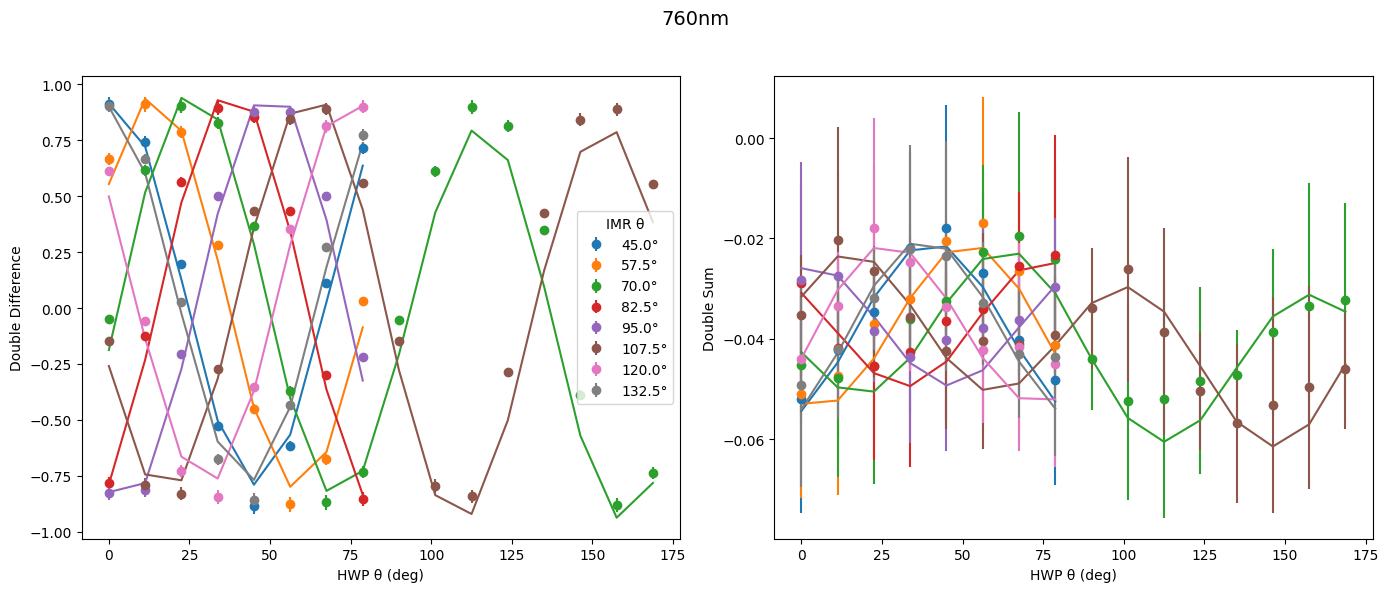

Before p0: {'dichroic': {'phi': -1.1447104924699028, 'epsilon': 0.04231883352999419, 'theta': 6.109835735508723}, 'flc': {'phi': 3.501713541084495, 'delta_theta': 4.999999984991414}, 'optics': {'phi': 1.767270636607728, 'epsilon': 1.0622706370803678e-12, 'theta': -4.777812739291021}, 'image_rotator': {'phi': 3.152932333349425}, 'hwp': {'phi': 2.916834658011647, 'delta_theta': -2.1036831646391683}, 'lp': {'theta': -5.0}}
Iteration #: 9
logl_value: 1384.5423496937728
Best Fit Parameters: [-1.14471049e+00  4.23188335e-02  6.10983574e+00  3.50171354e+00
  4.99999998e+00  1.76727064e+00  1.06227064e-12 -4.77781274e+00
  3.15293233e+00  2.91683466e+00 -2.10368316e+00 -5.00000000e+00]
Stopping: logl did not improve over the previous iteration.


In [7]:
# Unpolarized light for s_in as there is LP in the system already
s_in = np.array([1, 0, 0, 0])
bounds_dict = {
    "dichroic": {
        "phi": (-2 * np.pi, 2 * np.pi),
        "epsilon": (0, 1),
        "theta": (-90, 90)
    },
    "flc": {
        "phi": (0.4 * 2 * np.pi, 0.6 * 2 * np.pi),
        "delta_theta": (-5, 5)
    },
    "optics": {
        "phi": (-2 * np.pi, 2 * np.pi),
        "epsilon": (0, 1),
        "theta": (-90, 90)
    },
    "image_rotator": {
        "phi": (delta_derot - abs(delta_derot) * 0.1, delta_derot + abs(delta_derot) * 0.1),
    },
    "hwp": {
        "phi": (delta_HWP - abs(delta_HWP) * 0.1, delta_HWP + abs(delta_HWP) * 0.1),
        "delta_theta": (-5, 5)
    },
    "lp": {
        "theta": (-5, 5)
    }
}

# Now flatten the bounds in the same order as p0_keywords
p0_values, p0_keywords = inst.parse_configuration(p0)
for (comp, param), val in zip(p0_keywords, p0_values):
    lower, upper = bounds_dict[comp][param]
    if not (lower <= val <= upper):
        print(f"{comp}.{param} = {val} is outside bounds {lower} to {upper}")
bounds = [bounds_dict[comp][param] for comp, param in p0_keywords]

# Counters for iterative fitting
iteration = 1
previous_logl_value = np.inf
new_logl_value = None
best_result = None

while True:
    print("Before p0: " + str(p0))
    result, new_logl_value = inst.minimize_system_mueller_matrix(p0, system_mm, 
        interleaved_values, interleaved_stds, configuration_list, s_in = s_in,
        process_dataset = inst.process_dataset, 
        process_errors = inst.process_errors, 
        process_model = inst.process_model, bounds = bounds)
    new_logl_value = float(new_logl_value)
    
    # Print statements
    print("Iteration #: " + str(iteration))
    print("logl_value: " + str(new_logl_value))
    print("Best Fit Parameters: " + str(result.x))

    if new_logl_value >= previous_logl_value:
        print("Stopping: logl did not improve over the previous iteration.")
        if best_result is not None:
            result = best_result
        break

    previous_logl_value = new_logl_value
    best_result = result

    # Updating p0 and saving the latest best fit before plotting.
    inst.update_p0(p0, result.x)
    print("After p0: " + str(p0))

    filename = saved_fit_filename
    with open(filename, 'w') as f:
        json.dump(p0, f, indent=4)
    print("Saved latest best fit to: " + filename)

    # Making a plot
    updated_system_mm = inst.update_system_mm(result.x, p0_keywords, system_mm)
    model = inst.model(result.x, p0_keywords, updated_system_mm, configuration_list, 
    process_model = inst.process_model)

    inst.plot_data_and_model(interleaved_values, interleaved_stds, model, 
        configuration_list, wavelength = wavelength_string)

    iteration += 1


# Step 6: Plot model with best fit

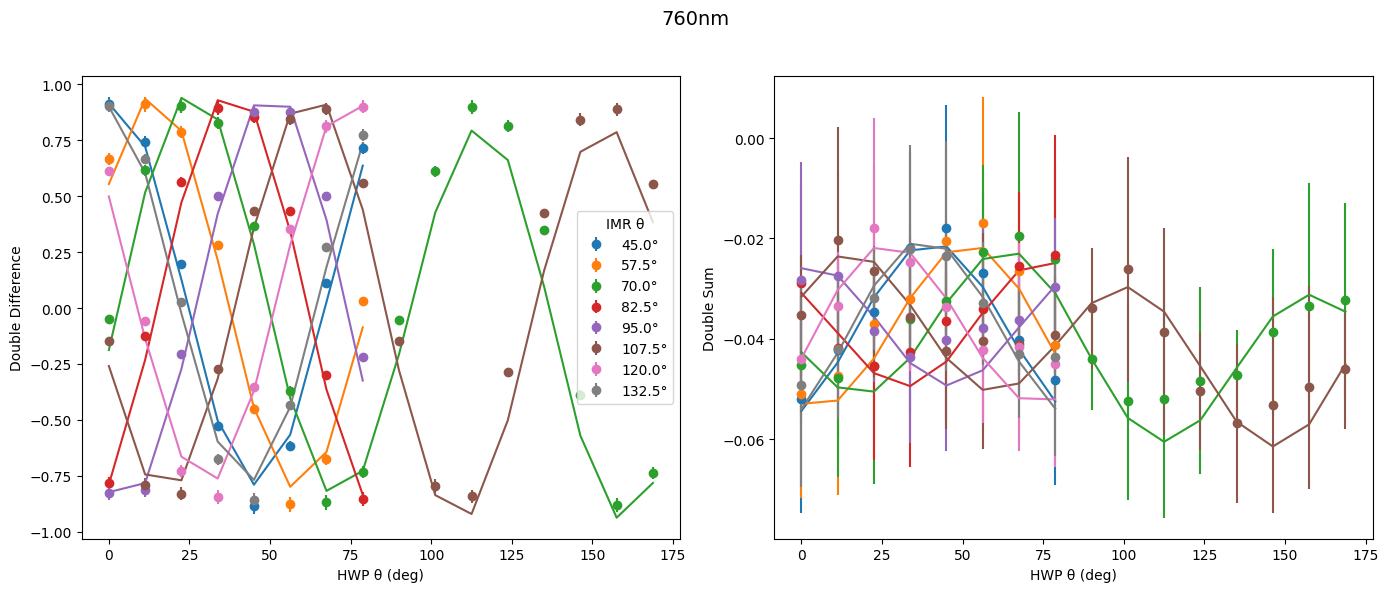

In [8]:
# Generate model with p0 keywords but scipy minimized results
# print(result.x)
# print(p0_keywords)

# Manually adjusting for a good fit
dichroic_phi = 0 # (waves)
dichroic_theta = 0 # (degrees)
# result.x = [2 * np.pi * dichroic_phi, dichroic_theta]

updated_system_mm = inst.update_system_mm(result.x, p0_keywords, system_mm)
model = inst.model(result.x, p0_keywords, system_mm, configuration_list, 
    process_model = inst.process_model)

inst.plot_data_and_model(interleaved_values, interleaved_stds, model, 
    configuration_list, wavelength = wavelength_string)